## Imports

Use ```pip install factor-analyzer``` to install the factor_analyzer package. This package is used to perform factor analysis with the ULS method, which is not implemented in sklearn. At the time of writing, the latest version of factor_analyzer is 0.5.1.

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
#version for factor_analyser: 0.5.1
from factor_analyzer import FactorAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
pd.options.display.max_columns = 70
pd.options.display.float_format = '{:.5f}'.format

# Data cleaning

In [2]:
data_raw = pd.read_csv('./IPIP-FFM-data-8Nov2018/data-final.csv', sep='\t')

In [10]:
#Select columns to only keep the 50 items that measure the 5 personality traits. 
#See codebook.txt for more details on all the columns.
data = data_raw.iloc[:, :50]

#We remove all lines where IPC is not 1, as these could be multiple submissions of the same person.
#The total number of lines in the original dataset is 1 015 341, and 696 845 after cleaning.
print("Number lines removed to avoid multiple submission : ", np.sum(data_raw.IPC != 1))
data = data[data_raw.IPC == 1]

#We remove lines where data is missing
n_before = len(data)
data = data.dropna()
n_after = len(data)
print("Number lines removed to avoid missing data : ", n_before - n_after)

#NE GARDE QUE LE 100 000 PREMIERS LIGNES POUR ACCELERER LES CALCULS (A enlever pour l'analyse finale)
data = data.iloc[:, :]
data_np = data.to_numpy()
data

Number lines removed to avoid multiple submission :  318496
Number lines removed to avoid missing data :  1141


,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,EST1,EST2,EST3,EST4,EST5,EST6,EST7,EST8,EST9,EST10,AGR1,AGR2,AGR3,AGR4,AGR5,AGR6,AGR7,AGR8,AGR9,AGR10,CSN1,CSN2,CSN3,CSN4,CSN5,CSN6,CSN7,CSN8,CSN9,CSN10,OPN1,OPN2,OPN3,OPN4,OPN5,OPN6,OPN7,OPN8,OPN9,OPN10
0,4.00000,1.00000,5.00000,2.00000,5.00000,1.00000,5.00000,2.00000,4.00000,1.00000,1.00000,4.00000,4.00000,2.00000,2.00000,2.00000,2.00000,2.00000,3.00000,2.00000,2.00000,5.00000,2.00000,4.00000,2.00000,3.00000,2.00000,4.00000,3.00000,4.00000,3.00000,4.00000,3.00000,2.00000,2.00000,4.00000,4.00000,2.00000,4.00000,4.00000,5.00000,1.00000,4.00000,1.00000,4.00000,1.00000,5.00000,3.00000,4.00000,5.00000
1,3.00000,5.00000,3.00000,4.00000,3.00000,3.00000,2.00000,5.00000,1.00000,5.00000,2.00000,3.00000,4.00000,1.00000,3.00000,1.00000,2.00000,1.00000,3.00000,1.00000,1.00000,4.00000,1.00000,5.00000,1.00000,5.00000,3.00000,4.00000,5.00000,3.00000,3.00000,2.00000,5.00000,3.00000,3.00000,1.00000,3.00000,3.00000,5.00000,3.00000,1.00000,2.00000,4.00000,2.00000,3.00000,1.00000,4.00000,2.00000,5.00000,3.00000
2,2.00000,3.00000,4.00000,4.00000,3.00000,2.00000,1.00000,3.00000,2.00000,5.00000,4.00000,4.00000,4.00000,2.00000,2.00000,2.00000,2.00000,2.00000,1.00000,3.00000,1.00000,4.00000,1.00000,4.00000,2.00000,4.00000,1.00000,4.00000,4.00000,3.00000,4.00000,2.00000,2.00000,2.00000,3.00000,3.00000,4.00000,2.00000,4.00000,2.00000,5.00000,1.00000,2.00000,1.00000,4.00000,2.00000,5.00000,3.00000,4.00000,4.00000
3,2.00000,2.00000,2.00000,3.00000,4.00000,2.00000,2.00000,4.00000,1.00000,4.00000,3.00000,3.00000,3.00000,2.00000,3.00000,2.00000,2.00000,2.00000,4.00000,3.00000,2.00000,4.00000,3.00000,4.00000,2.00000,4.00000,2.00000,4.00000,3.00000,4.00000,2.00000,4.00000,4.00000,4.00000,1.00000,2.00000,2.00000,3.00000,1.00000,4.00000,4.00000,2.00000,5.00000,2.00000,3.00000,1.00000,4.00000,4.00000,3.00000,3.00000
5,3.00000,3.00000,4.00000,2.00000,4.00000,2.00000,2.00000,3.00000,3.00000,4.00000,3.00000,4.00000,3.00000,2.00000,2.00000,1.00000,2.00000,1.00000,2.00000,2.00000,2.00000,3.00000,1.00000,4.00000,2.00000,3.00000,2.00000,3.00000,4.00000,4.00000,3.00000,2.00000,4.00000,1.00000,3.00000,2.00000,4.00000,3.00000,4.00000,3.00000,5.00000,1.00000,5.00000,1.00000,3.00000,1.00000,5.00000,4.00000,5.00000,2.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015334,4.00000,1.00000,4.00000,2.00000,4.00000,3.00000,3.00000,2.00000,3.00000,2.00000,2.00000,4.00000,3.00000,2.00000,5.00000,2.00000,4.00000,3.00000,1.00000,2.00000,1.00000,4.00000,4.00000,5.00000,2.00000,5.00000,3.00000,4.00000,5.00000,3.00000,3.00000,2.00000,3.00000,4.00000,3.00000,2.00000,4.00000,3.00000,4.00000,4.00000,3.00000,3.00000,5.00000,3.00000,4.00000,2.00000,5.00000,2.00000,3.00000,4.00000
1015335,5.00000,1.00000,5.00000,2.00000,4.00000,2.00000,3.00000,1.00000,5.00000,1.00000,5.00000,2.00000,5.00000,2.00000,5.00000,4.00000,5.00000,5.00000,5.00000,4.00000,1.00000,5.00000,5.00000,4.00000,2.00000,4.00000,2.00000,3.00000,4.00000,5.00000,2.00000,5.00000,4.00000,3.00000,3.00000,4.00000,3.00000,3.00000,2.00000,4.00000,4.00000,1.00000,4.00000,2.00000,3.00000,2.00000,5.00000,3.00000,4.00000,4.00000
1015337,4.00000,3.00000,4.00000,3.00000,3.00000,3.00000,4.00000,4.00000,3.00000,3.00000,4.00000,3.00000,5.00000,1.00000,5.00000,5.00000,4.00000,4.00000,4.00000,5.00000,2.00000,4.00000,1.00000,4.00000,3.00000,5.00000,3.00000,3.00000,5.00000,3.00000,3.00000,2.00000,3.00000,4.00000,3.00000,3.00000,2.00000,3.00000,2.00000,3.00000,4.00000,1.00000,5.00000,1.00000,5.00000,1.00000,3.00000,4.00000,5.00000,4.00000
1015339,2.00000,4.00000,3.00000,4.00000,2.00000,2.00000,1.00000,4.00000,2.00000,4.00000,4.00000,3.00000,4.00000,2.00000,4.00000,4.00000,2.00000,2.00000,4.00000,4.00000,2.00000,3.00000,2.00000,4.00000,3.00000,4.00000,2.00000,4.00000,4.00000,3.00000,4.00000,2.00000,4.00000,2.00000,2.00000,2.00000,4.00000,2.

# Factor analysis

We perform factor analysis on the data to reduce the dimensionnality of the data. In pychological terms, it means that to find the underlying fundamental personality traits that (partially) explain the responses to the questions.

## Note on rotation and interfactorial correlations

We apply factor analysis to the data, to extract the Big Five personality traits, with varimax rotation to make the traits more interpretable.

We could have used non orthogonal rotation methods, like oblimin which allow for correlated factors. It is commonly recommended to use oblique rotation in psychometric analysis, as said in Fabrigar et al. (https://doi.org/10.1037/1082-989X.4.3.272): 
>*For many constructs examined in psychology (e.g., mental abilities, personality traits, attitudes), there is substantial theoretical and empirical basis for expecting these constructs (or dimensions of these constructs) to be correlated with one another. Therefore, oblique rotations provide a more accurate and realistic representation of how constructs are likely to be related to one another.*

However, our goal here is not to explain the correlations between factors, but to perform clustering on the factors, and we fear that oblique rotation will deform the space in way that will influence the clustering. [MAYBE NOT FOR FULL MATRIX GMM, TO CHECK]
Additionally, Costello et Osborne (https://doi.org/10.1037/1082-989X.4.3.272) suggest that orthogonal and oblique rotation often produce similar results so we will not loose much interpretability by using varimax rotation. The results given in appendix B of this notebook agree with this statement.

## Note on the factor analysis extraction method

FactorAnalyser from factor_analyser use ULS method (or minres, or iterated principal factor method) to perform factor analysis, which does not assume that factors are normally distributed, contrarily to the maximum likelihood method. 
And since the assumption that factor follows Gaussian distribution directly contradicts the assumption of the Gaussian mixture model that we will use later, we think that it is preferable to use the ULS method. However, this don't seem to bother Gerlach, M., Farb, B., Revelle, W. et al. (https://doi.org/10.1038/s41562-018-0419-z), who use the ML method before using GMM. For the sake of comparison, we also perform factor analysis with the ML method in the appendix A of this notebook, and the results are very similar to the ones given by the ULS method.

**Possible bug**: FactorAnalyzer use sklearn.utils.check_array's old parameter ```force_all_finite``` which have been renamed to ```ensure_all_finite``` in sklearn 1.6. 

You can either modify the source code of factor_analyzer in factor_analyser.py (locate this file with the error message then replace each occurrence of 'force_all_finite' by 'ensure_all_finite') or downgrade sklearn to 1.6.

## How many factors to extract?

A common method to determine the number of factors to extract is to look at the scree plot, which is a plot of the eigenvalues of the correlation matrix of the data. The eigenvalues represent the amount of variance explained by each factor. The usual rule is to look for the "elbow" in the scree plot, which is the point where the eigenvalues start to level off. 

Eigenvalues :  [7.31543484 5.00342349 3.90529274 3.50185974 2.79209833 1.92874544
 1.32379645 1.02020242 0.9481793  0.90700577 0.87948645 0.83488766
 0.81885291 0.79784353 0.77802749 0.73449318 0.72006985 0.69595495
 0.67968696 0.65220482 0.64102497 0.63672114 0.60482094 0.60057248
 0.58998593 0.56378251 0.54615096 0.53186483 0.52676501 0.51508789
 0.50254717 0.49123013 0.48638359 0.45857279 0.44087367 0.43131211
 0.42918562 0.42050377 0.41135823 0.40939521 0.39961143 0.38263607
 0.38028487 0.37719815 0.37404551 0.35736902 0.35306258 0.34228399
 0.32842286 0.22940025]


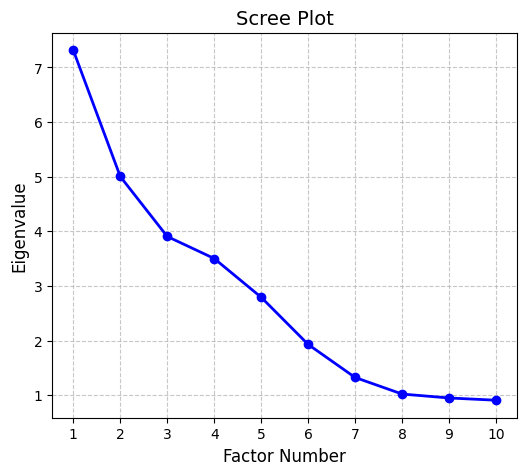

In [5]:
#The ULS method have several names: minres, iterated principal factor method or unweighted least squares method.
fa = FactorAnalyzer(n_factors=5, rotation='varimax', method='minres', svd_method='lapack') 

#We create a new dataframe with the 5 personality traits as columns, and the same index as the original data.
data_fa = pd.DataFrame(fa.fit_transform(data_np))
eigenvalues, _ = fa.get_eigenvalues()
print("Eigenvalues : ", eigenvalues)
#plot the ten first eigenvalue in a scree plot:

top_10_eigenvalues = eigenvalues[:10]
factors = range(1, len(top_10_eigenvalues) + 1)

plt.figure(figsize=(6, 5))
plt.plot(factors, top_10_eigenvalues, marker='o', linestyle='-', color='b', linewidth=2)

plt.title('Scree Plot', fontsize=14)
plt.xlabel('Factor Number', fontsize=12)
plt.ylabel('Eigenvalue', fontsize=12)
plt.xticks(factors)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Looking at the scree plot, it is not clear that we should extract five factors, the solution with six or seven factors also seems plausible. One solution would be to look at the VSS (Very Simple Structure) criterion or, even better, to look at Velicer's MAP (Minimum Average Partial) test, which is a more robust method to determine the number of factors to extract. These methode are not implemented in Python, however, they are implemented in R in the psych package. Look at factor_analysis.qmd for the R code to perform these tests.

Since the number of factors to extract is not clear, we will perform factor analysis with five factors, according to the scientific consensus.

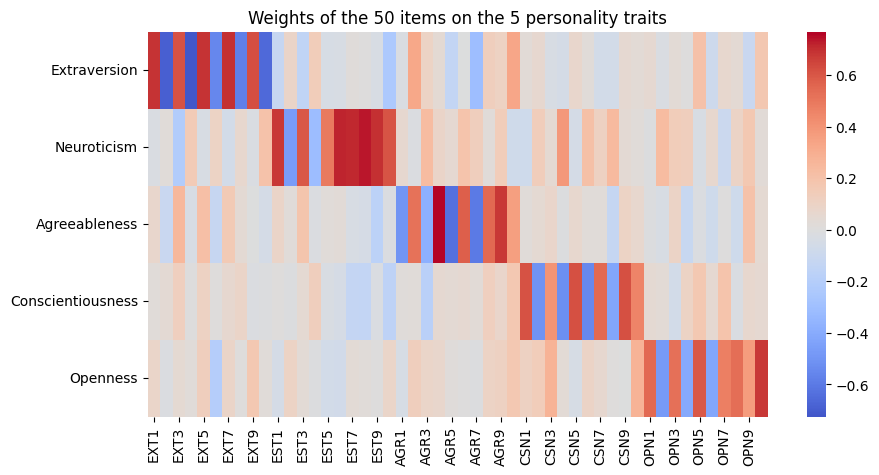

In [26]:
#plot the weights of the 50 items on the 5 personality traits as a heatmap
weights = pd.DataFrame(fa.loadings_.T, columns=data.columns, index=['Extraversion','Neuroticism','Agreeableness','Conscientiousness','Openness']) #FactorAnalyzer's loading transposed is equivalent to sklearn's components_.

plt.figure(figsize=(10, 5))
sns.heatmap(weights, cmap='coolwarm', center=0)
plt.title('Weights of the 50 items on the 5 personality traits')
plt.show()

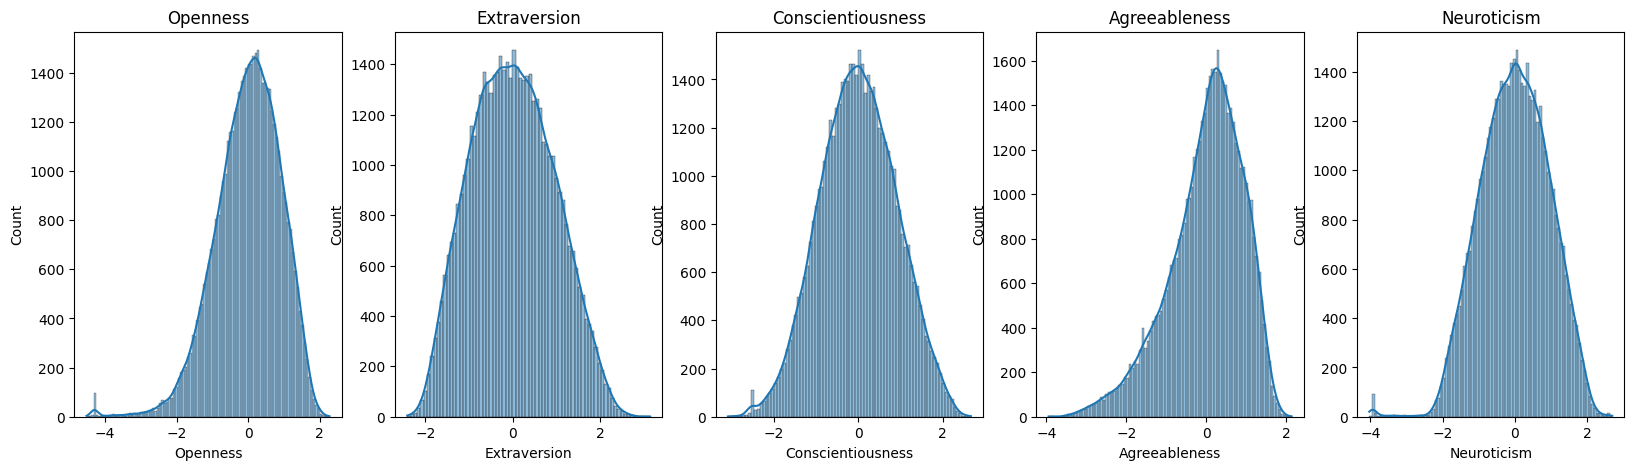

In [27]:
#From the previous plot, we can infer that factors are ordered as follow:
data_fa.columns = ['Extraversion','Neuroticism','Agreeableness','Conscientiousness','Openness']
#plot the distribution of the 5 personality traits in 5 subplots
fig, axs = plt.subplots(1, 5, figsize=(20, 5))
sns.histplot(data_fa['Openness'], ax=axs[0], kde=True)
sns.histplot(data_fa['Conscientiousness'], ax=axs[2], kde=True)
sns.histplot(data_fa['Extraversion'], ax=axs[1], kde=True)
sns.histplot(data_fa['Agreeableness'], ax=axs[3], kde=True)
sns.histplot(data_fa['Neuroticism'], ax=axs[4], kde=True)
axs[0].set_title('Openness')
axs[2].set_title('Conscientiousness')
axs[1].set_title('Extraversion')
axs[3].set_title('Agreeableness')
axs[4].set_title('Neuroticism')
plt.show()

## APPENDIX A: Comparison of the results provided by ULS vs ML extraction methods for factor analysis

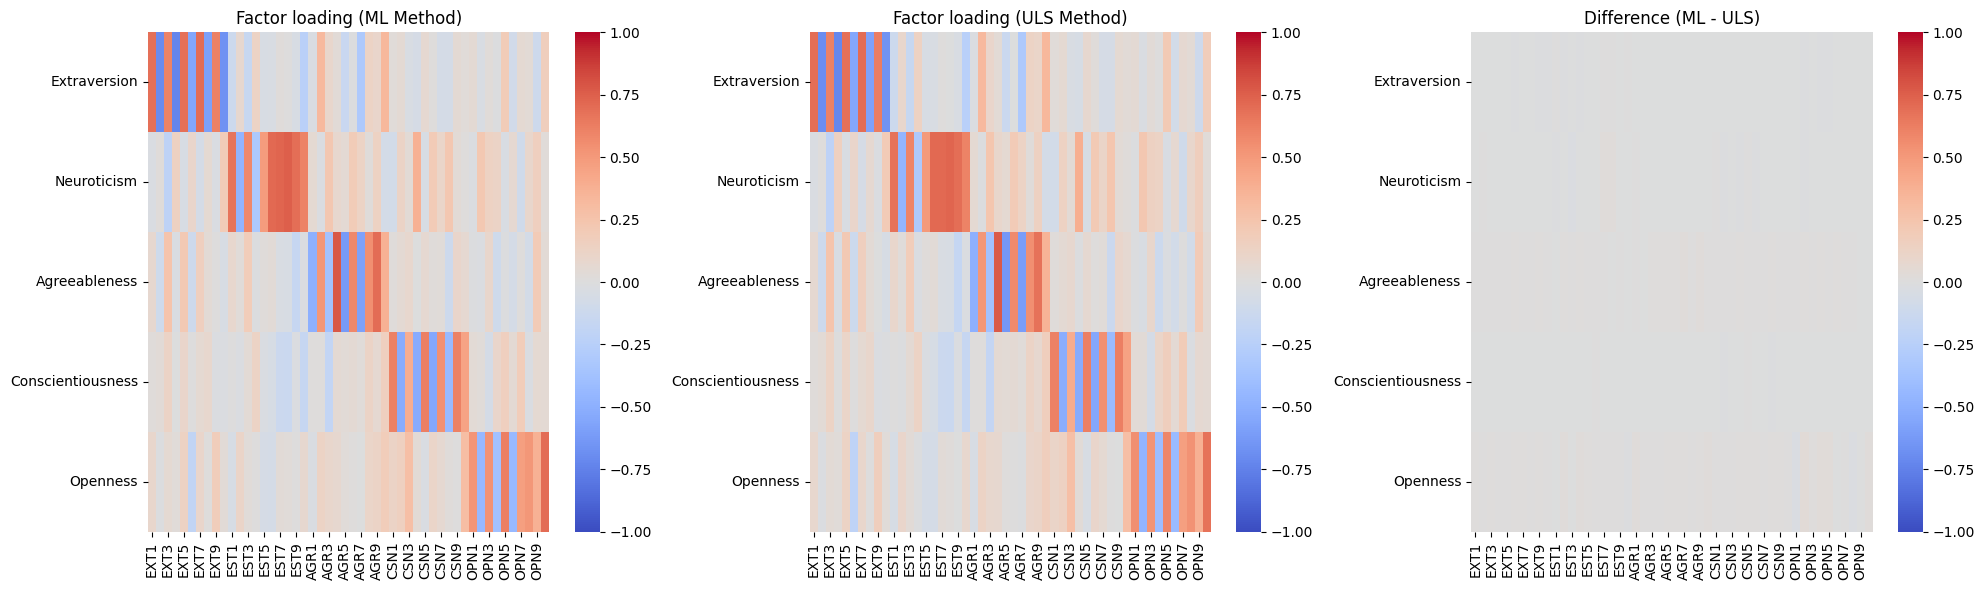

Difference between the weights of the ML method and the ULS method : 



,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,EST1,EST2,EST3,EST4,EST5,EST6,EST7,EST8,EST9,EST10,AGR1,AGR2,AGR3,AGR4,AGR5,AGR6,AGR7,AGR8,AGR9,AGR10,CSN1,CSN2,CSN3,CSN4,CSN5,CSN6,CSN7,CSN8,CSN9,CSN10,OPN1,OPN2,OPN3,OPN4,OPN5,OPN6,OPN7,OPN8,OPN9,OPN10
Extraversion,-0.00443,-0.00315,-0.00495,-0.00343,-0.00204,-0.00916,-0.00037,-0.00165,-0.01020,-0.01000,0.00065,-0.01073,-0.00153,-0.00967,-0.00369,-0.00209,0.00327,0.00327,-0.00433,0.00519,-0.00619,-0.00224,-0.00541,-0.00516,-0.00631,-0.00557,-0.00552,-0.00329,-0.00755,-0.00407,-0.00305,-0.00715,-0.00485,-0.00764,-0.00173,-0.00738,-0.00319,-0.00609,-0.00371,-0.00513,-0.00054,-0.01218,-0.00572,-0.01134,-0.01009,-0.00242,-0.00416,-0.00036,-0.00244,-0.00763
Neuroticism,-0.00149,0.00058,-0.00025,-0.00434,-0.00391,-0.00200,-0.00138,-0.00267,-0.00365,-0.00496,-0.01372,-0.00669,-0.01563,-0.00514,-0.00120,-0.00149,0.02124,0.01825,-0.00184,-0.00250,0.00113,-0.00469,-0.00340,-0.00418,-0.00255,-0.00342,-0.00270,-0.00446,-0.00239,-0.00188,0.00073,-0.01096,-0.00356,-0.01102,0.00582,-0.01033,-0.00494,-0.00436,-0.00192,-0.00372,-0.00667,-0.00907,-0.00304,-0.00736,-0.00519,-0.00049,-0.00022,-0.00407,-0.00605,-0.00521
Agreeableness,0.00612,0.00403,0.00358,0.00542,0.00223,0.00943,0.00233,0.00126,0.01110,0.00551,-0.00318,0.01125,0.00085,0.01002,0.00283,0.00099,0.00008,-0.00028,0.00739,-0.00145,0.00466,-0.00133,0.00814,0.01142,0.01195,0.00787,0.01946,0.00295,0.01811,0.00507,0.00098,0.00550,0.00512,0.00900,0.00184,0.00535,0.00245,0.01046,0.00253,0.00142,0.00452,0.01090,0.00009,0.01282,0.00134,0.01073,0.00582,0.00512,-0.00065,-0.00240
Conscientiousness,-0.00124,-0.00341,-0.00186,-0.00503,-0.00161,-0.00313,-0.00119,-0.00333,-0.00274,-0.00544,-0.00045,-0.00643,-0.00404,-0.00211,-0.00095,0.00004,-0.00194,-0.00093,-0.00210,-0.00132,-0.00110,-0.00239,-0.00484,-0.00348,-0.00393,-0.00311,-0.00539,-0.00491,-0.00461,-0.00478,-0.00149,-0.00944,-0.00595,-0.00339,0.00003,-0.00625,-0.00205,-0.00787,-0.00098,-0.00733,-0.00381,-0.00544,-0.00250,-0.00506,-0.00593,-0.00170,-0.00647,-0.00448,-0.00424,-0.00457
Openness,0.01078,0.00592,0.01159,0.00524,0.00712,0.01248,0.00793,0.00422,0.00815,0.00764,-0.00218,0.01767,-0.00338,0.01914,0.01071,0.00347,0.00387,0.00255,0.00251,-0.00851,0.01673,0.00213,0.00486,0.00383,0.01354,0.01231,0.01063,0.00780,0.00803,0.01669,0.00453,0.00718,0.00267,0.00797,0.01127,0.01211,0.00237,0.00982,0.00881,0.00708,-0.02505,0.03480,0.00819,0.02788,0.03096,-0.00258,0.00133,-0.02277,-0.00141,0.02134


In [28]:
#Perform factor analysis with the maximum likelihood (ML) method, for comparison with the ULS method.
fa_ml = FactorAnalyzer(n_factors=5, rotation='varimax', method='ml', svd_method='lapack') #sklearn's FactorAnalysis use the maximum likelihood method to perform factor analysis, which assume that factors are normally distributed, contrarily to the ULS method used above.
data_fa_ml = pd.DataFrame(fa_ml.fit_transform(data_np))

#Technical manipulations to make results of the ML method comparable to the ULS method:
#Invert the 4th and 5th factors of the ML method, to match the order of the factors given by the ULS method:
data_fa_ml = data_fa_ml.iloc[:, [0, 1, 2, 4, 3]]
fa_ml.loadings_ = fa_ml.loadings_[:, [0, 1, 2, 4, 3]]

#From our observations (just look at which group of question links to which factor), factor are ordered as follows:
data_fa_ml.columns = ['Extraversion','Neuroticism','Agreeableness','Openness','Conscientiousness']
weights_ml = pd.DataFrame(fa_ml.loadings_.T, columns=data.columns, index=['Extraversion','Neuroticism','Agreeableness','Openness','Conscientiousness'])
weights_ml = weights_ml.reindex(['Extraversion','Neuroticism','Agreeableness','Conscientiousness','Openness'])
data_fa_ml = data_fa_ml.reindex(['Extraversion','Neuroticism','Agreeableness','Conscientiousness','Openness'], axis=1)

#Loading matrix plots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
heatmap_kwargs = {
    'cmap': 'coolwarm',
    'center': 0,
    'vmin': -1,
    'vmax': 1,
    'cbar': True
}
sns.heatmap(weights_ml, ax=ax1, **heatmap_kwargs)
ax1.set_title('Factor loading (ML Method)')
sns.heatmap(weights, ax=ax2, **heatmap_kwargs)
ax2.set_title('Factor loading (ULS Method)')
sns.heatmap(weights_ml - weights, ax=ax3, **heatmap_kwargs)
ax3.set_title('Difference (ML - ULS)')
plt.tight_layout()
plt.show()
print("Difference between the weights of the ML method and the ULS method : \n")
weights_ml - weights

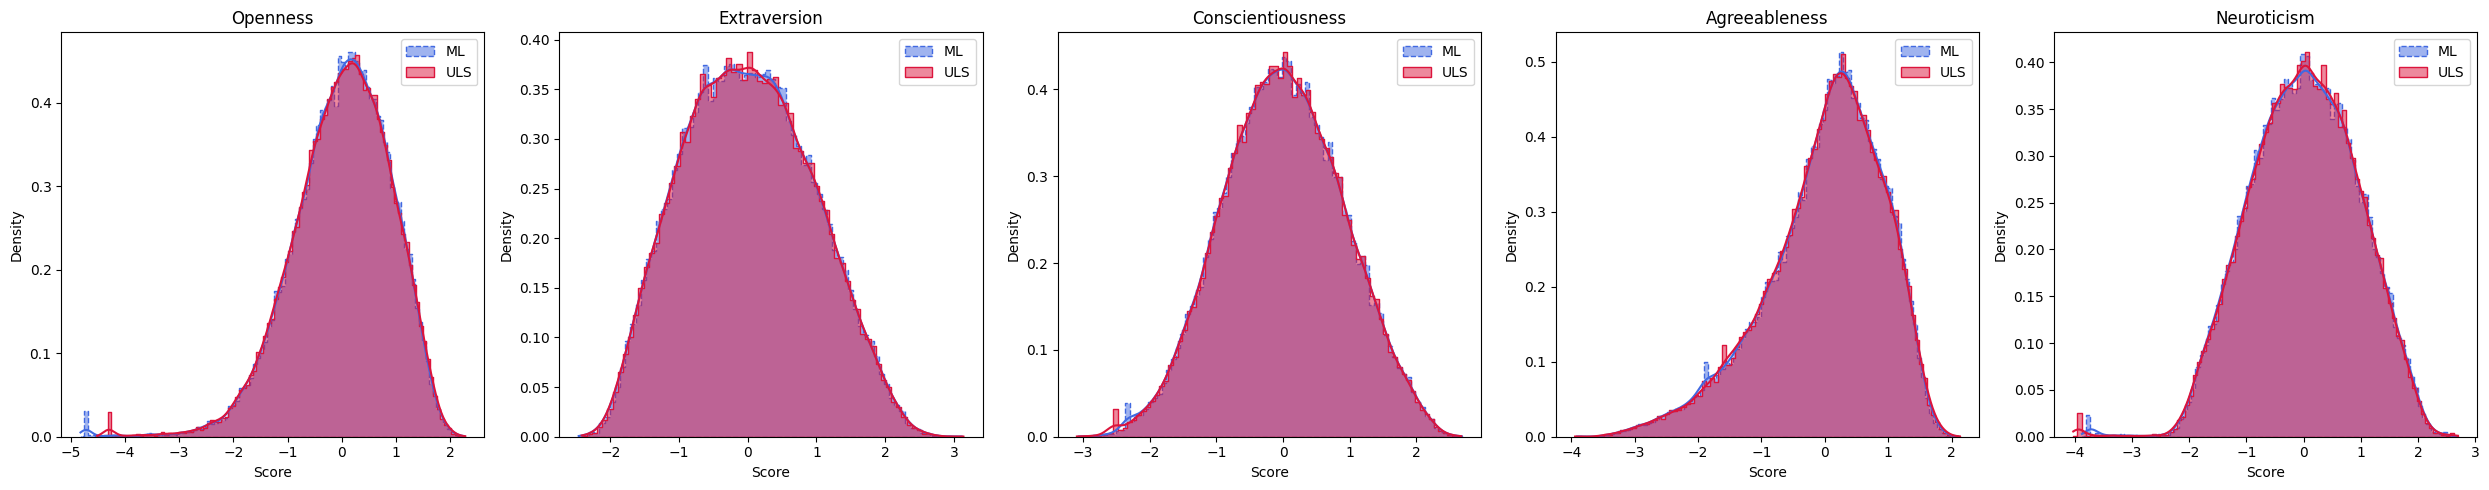

In [29]:
#Histogram plots
fig, axs = plt.subplots(1, 5, figsize=(25, 5))
traits = ['Openness', 'Extraversion', 'Conscientiousness', 'Agreeableness', 'Neuroticism']
for i, trait in enumerate(traits):
    sns.histplot(data_fa_ml[trait], ax=axs[i], kde=True, 
                 color='royalblue', label='ML', alpha=0.5, stat="density", element="step", linestyle='dashed')
    sns.histplot(data_fa[trait], ax=axs[i], kde=True, 
                 color='crimson', label='ULS', alpha=0.5, stat="density", element="step")
    axs[i].set_title(trait)
    axs[i].set_xlabel('Score')
    axs[i].legend() 
plt.tight_layout()
plt.show()

We can see that the loadings and distributions of the factor with ULS method are very similar to the ones given by the factor analysis with ML method, which suggest that the choice of the extraction method does not have a strong influence on the results. However, we think that it is preferable to use the ULS method, since it does not assume that factors are normally distributed, which is more consistent with the assumptions of the gaussian mixture model that we will use later.

# Appendix B: Comparison of the results provided by varimax vs oblimin rotation methods for factor analysis

In the main part of the notebook, we use orthogonal rotation (varimax, to be specific) to make the factors more interpretable. However, we could have used oblique (oblimin here) rotation which allow for correlated factors. We will see that the results given by the oblimin rotation are very similar to the ones given by the varimax rotation, which suggest that the choice of the rotation method does not have a strong influence on the results.

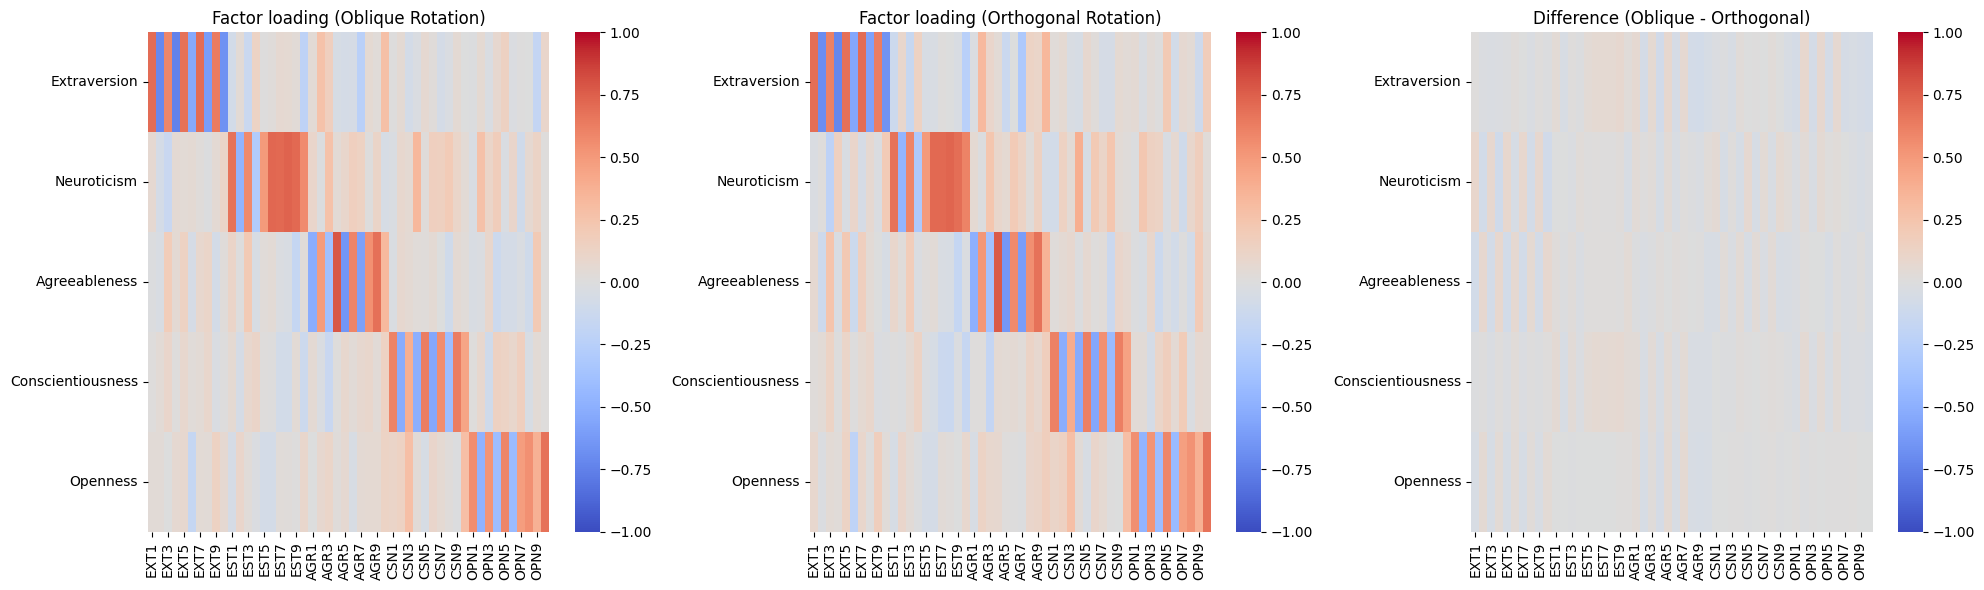

Difference between the weights of the varimax and the oblimin rotation : 



,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,EST1,EST2,EST3,EST4,EST5,EST6,EST7,EST8,EST9,EST10,AGR1,AGR2,AGR3,AGR4,AGR5,AGR6,AGR7,AGR8,AGR9,AGR10,CSN1,CSN2,CSN3,CSN4,CSN5,CSN6,CSN7,CSN8,CSN9,CSN10,OPN1,OPN2,OPN3,OPN4,OPN5,OPN6,OPN7,OPN8,OPN9,OPN10
Extraversion,0.01272,-0.01663,-0.02348,-0.02194,-0.01164,0.02093,-0.00163,-0.02892,0.00801,-0.01298,0.04195,-0.04587,0.01244,-0.01385,0.04209,0.05787,0.05547,0.05944,0.07222,0.02718,0.06852,-0.06299,0.05859,-0.09247,0.07260,-0.05509,0.06907,-0.07071,-0.07960,-0.05412,-0.02217,-0.00905,-0.04194,0.02500,-0.00416,0.00446,-0.00558,0.03042,-0.00638,-0.03979,-0.06310,0.07833,-0.06265,0.07401,-0.06316,0.06253,-0.06225,-0.04546,-0.06238,-0.07766
Neuroticism,0.08716,-0.08359,0.07169,-0.09690,0.08150,-0.05270,0.08423,-0.07501,0.07494,-0.08628,-0.00441,-0.00690,-0.01818,0.02723,0.00553,0.00819,0.00530,0.00513,0.02116,-0.04041,0.03861,0.00121,0.02422,-0.04788,0.03134,-0.03357,0.00789,-0.01548,-0.03124,0.02448,0.05361,-0.05128,0.01274,-0.05168,0.06763,-0.05357,0.04191,-0.03620,0.06231,0.02724,-0.02162,0.03742,-0.03836,0.04759,0.00823,0.02744,-0.00391,-0.02133,-0.04367,-0.01615
Agreeableness,-0.07903,0.07332,-0.07222,0.08196,-0.08086,0.06346,-0.08012,0.06247,-0.07387,0.07477,0.02213,-0.01389,0.02316,-0.02685,0.01177,0.01468,0.01033,0.01209,0.00475,0.04056,-0.01312,-0.02448,-0.01183,0.01568,-0.00688,0.01702,0.01465,-0.00738,0.00333,-0.04136,-0.04546,0.02639,-0.02545,0.04200,-0.04618,0.03375,-0.02834,0.03228,-0.04311,-0.03701,-0.02054,0.01055,-0.00615,-0.00156,-0.04681,0.01268,-0.03009,-0.01616,0.00852,-0.03483
Conscientiousness,-0.00786,0.00644,-0.02948,0.00849,-0.01909,0.02604,-0.01592,0.00083,-0.01001,0.01329,0.04946,-0.04310,0.03240,-0.01892,0.04027,0.05627,0.05184,0.05481,0.06269,0.03775,0.03738,-0.03877,0.03260,-0.04314,0.04187,-0.01909,0.04594,-0.03526,-0.03569,-0.03404,-0.00365,-0.01089,-0.01238,0.01796,0.00667,-0.00101,0.01275,0.01731,0.00915,-0.01266,-0.03490,0.05149,-0.03049,0.04597,-0.03655,0.03856,-0.03481,-0.02321,-0.02339,-0.04347
Openness,-0.04355,0.04808,-0.05136,0.04410,-0.05289,0.03600,-0.04996,0.03067,-0.03279,0.04100,-0.00625,-0.00024,-0.00919,-0.00462,-0.00453,-0.00779,-0.00386,-0.00261,0.00806,0.01205,0.03553,-0.05288,0.02107,-0.05654,0.05322,-0.04268,0.05940,-0.04523,-0.05386,-0.04174,-0.00135,-0.00391,0.00114,0.00252,-0.01030,-0.00096,0.00085,0.01150,-0.01195,-0.00182,0.00890,-0.00809,0.00100,-0.00138,0.00113,0.00125,0.00600,0.01334,-0.00186,-0.00028


In [32]:
#Perform factor analysis with the oblimin rotation method, for comparison with the varimax rotation method we used above.
fa_obli = FactorAnalyzer(n_factors=5, rotation='oblimin', method='uls', svd_method='lapack') #sklearn's FactorAnalysis use the maximum likelihood method to perform factor analysis, which assume that factors are normally distributed, contrarily to the ULS method used above.
data_fa_obli = pd.DataFrame(fa_obli.fit_transform(data_np))

#Technical manipulations to make results of the oblimin rotation comparable to the varimax rotation:
data_fa_obli = data_fa_obli.iloc[:, [0, 1, 2, 4, 3]]
fa_obli.loadings_ = fa_obli.loadings_[:, [0, 1, 2, 4, 3]]


#From our (not shown) observations, factor are ordered as follows:
data_fa_obli.columns = ['Extraversion','Neuroticism','Agreeableness','Openness','Conscientiousness']
weights_obli = pd.DataFrame(fa_obli.loadings_.T, columns=data.columns, index=['Extraversion','Neuroticism','Agreeableness','Openness','Conscientiousness'])
weights_obli = weights_obli.reindex(['Extraversion','Neuroticism','Agreeableness','Conscientiousness','Openness'])
data_fa_obli = data_fa_obli.reindex(['Extraversion','Neuroticism','Agreeableness','Conscientiousness','Openness'], axis=1)

#Loading matrix plots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
heatmap_kwargs = {
    'cmap': 'coolwarm',
    'center': 0,
    'vmin': -1,
    'vmax': 1,
    'cbar': True
}
sns.heatmap(weights_obli, ax=ax1, **heatmap_kwargs)
ax1.set_title('Factor loading (Oblique Rotation)') #the oblique rotation in question is the oblimin rotation.
sns.heatmap(weights, ax=ax2, **heatmap_kwargs)
ax2.set_title('Factor loading (Orthogonal Rotation)') #the orthogonal rotation in question is the varimax rotation.
sns.heatmap(weights_obli - weights, ax=ax3, **heatmap_kwargs)
ax3.set_title('Difference (Oblique - Orthogonal)')
plt.tight_layout()
plt.show()
print("Difference between the weights of the varimax and the oblimin rotation : \n")
weights_obli - weights

## Correlation between the factors obtained with the oblimin rotation

Unlike the factors obtained with the varimax rotation, the factors obtained with the oblimin rotation are correlated, as expected. However, the correlations between factors are not very strong, which suggest that the factors are still relatively independent from each other. This is consistent with the fact that the results given by the oblimin rotation are very similar to the ones given by the varimax rotation.
We give here a comparison of the correlation matrice we found with the one given by Van der Linden et al. in their 2010 meta-analysis (https://doi.org/10.1016/j.jrp.2010.03.003).

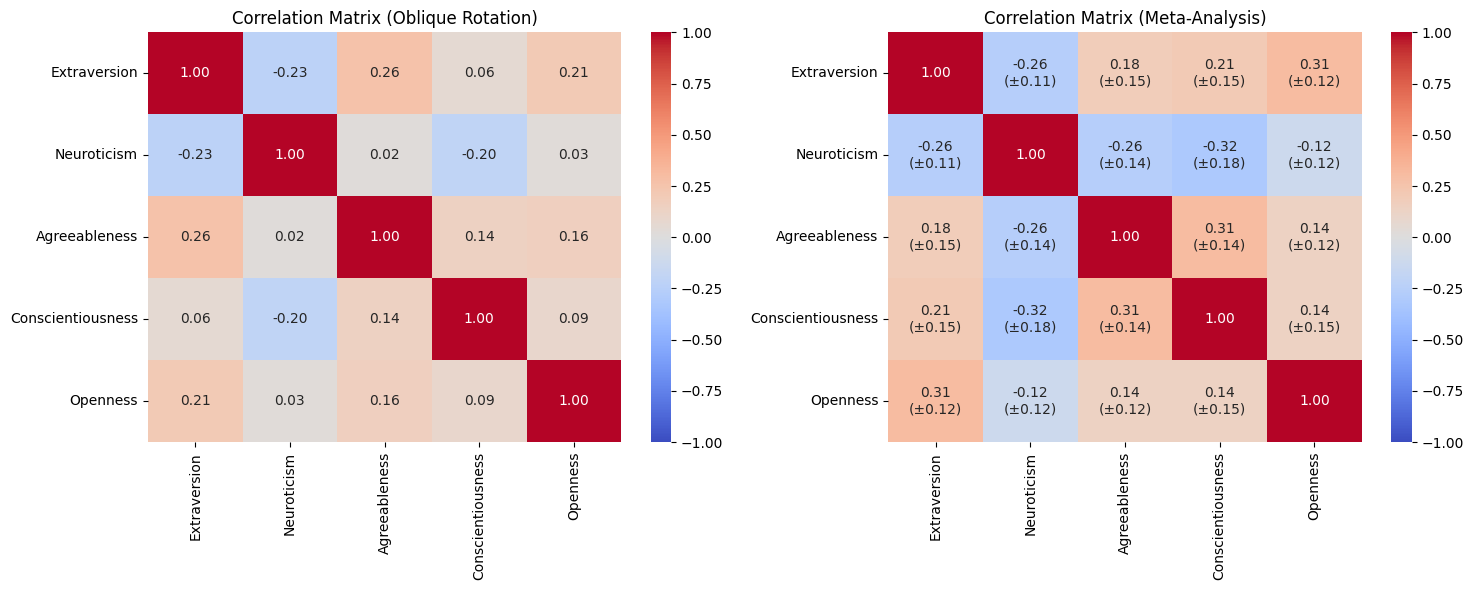

In [33]:
#plot the correlation matrix of the 5 personality traits obtained with the oblique rotation, to check that they are indeed correlated as expected.
#compute the correlation matrix of the 5 personality traits obtained with the oblique rotation
corr_ml = data_fa_obli.corr()

#(uncorrected) correlation matrix from the meta-analysis of Van der Linden et al. (2010):
corr_meta_analysis = pd.DataFrame([
    [ 1.00, -0.26,  0.18,  0.21,  0.31], # Extraversion
    [-0.26,  1.00, -0.26, -0.32, -0.12], # Neuroticism
    [ 0.18, -0.26,  1.00,  0.31,  0.14], # Agreeableness
    [ 0.21, -0.32,  0.31,  1.00,  0.14], # Conscientiousness
    [ 0.31, -0.12,  0.14,  0.14,  1.00]
], columns=['Extraversion', 'Neuroticism', 'Agreeableness', 'Conscientiousness', 'Openness'], 
   index=['Extraversion', 'Neuroticism', 'Agreeableness', 'Conscientiousness', 'Openness'])

sd_corr_meta_analysis = [
    [ 0.00,  0.11,  0.15,  0.15,  0.12], # Extraversion
    [ 0.11,  0.00,  0.14,  0.18,  0.12], # Neuroticism
    [ 0.15,  0.14,  0.00,  0.14,  0.12], # Agreeableness
    [ 0.15,  0.18,  0.14,  0.00,  0.15],
    [ 0.12,  0.12,  0.12,  0.15,  0.00]
]
#matrix of annotations for the heatmap of the meta-analysis correlation matrix
annot_matrix = np.array([
    [f"{p:.2f}" if i == j else f"{p:.2f}\n(±{sd:.2f})" 
     for j, (p, sd) in enumerate(zip(row_p, row_sd))]
    for i, (row_p, row_sd) in enumerate(zip(corr_meta_analysis.to_numpy(), sd_corr_meta_analysis))
])

#show the two correlation matrices side by side for comparison
#add standard deviation of the correlation coefficients from the meta-analysis as annotations on the heatmap of the meta-analysis correlation matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(corr_ml, ax=ax1, cmap='coolwarm', vmin=-1, vmax=1, annot=True, fmt=".2f", cbar=True)
ax1.set_title('Correlation Matrix (Oblique Rotation)')
sns.heatmap(corr_meta_analysis, ax=ax2, cmap='coolwarm', vmin=-1, vmax=1, annot=annot_matrix, fmt="", cbar=True)
ax2.set_title('Correlation Matrix (Meta-Analysis)')
plt.tight_layout()
plt.show()

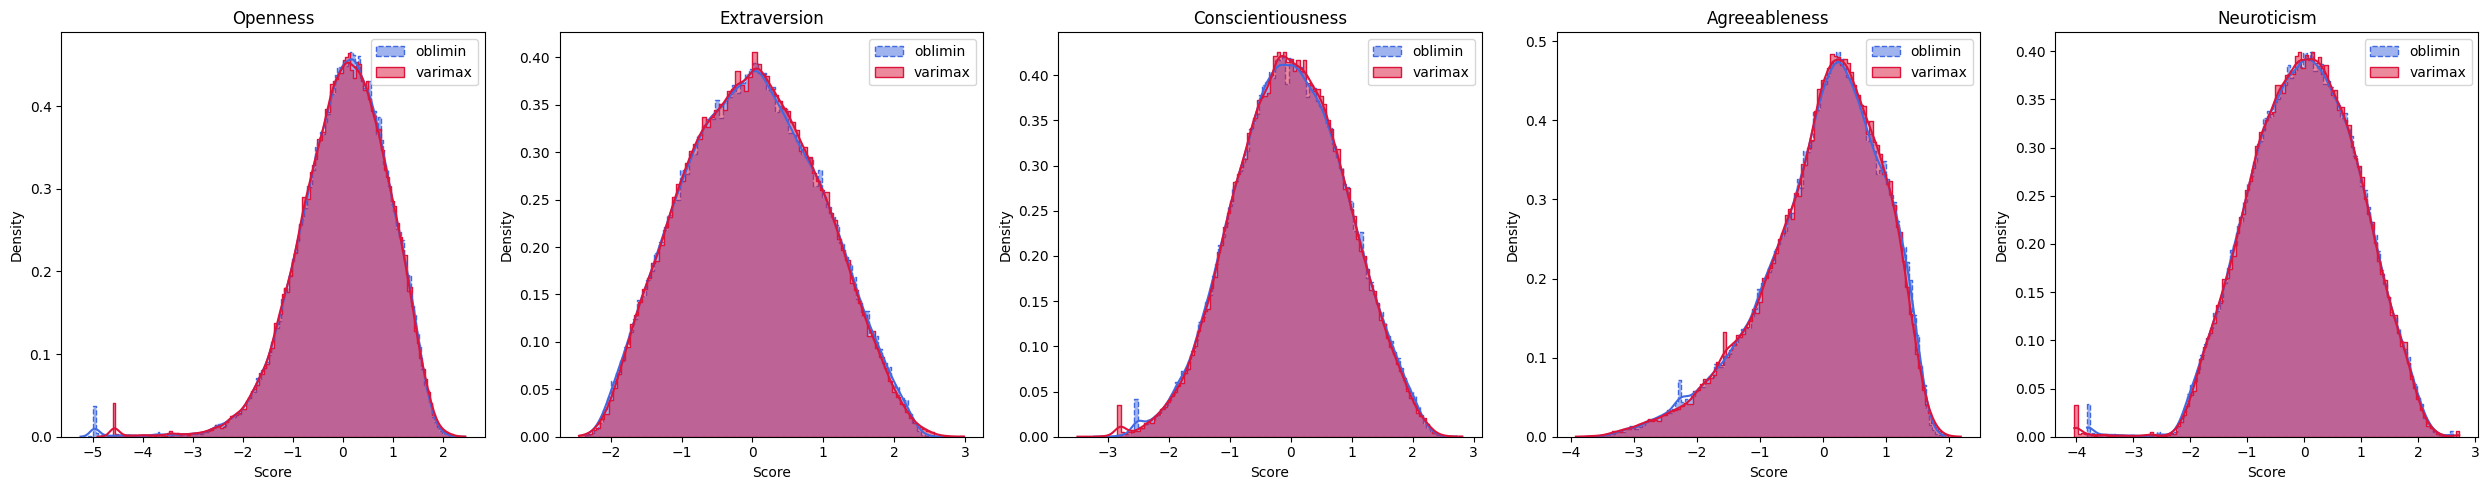

In [91]:
#Histogram plots
fig, axs = plt.subplots(1, 5, figsize=(25, 5))
traits = ['Openness', 'Extraversion', 'Conscientiousness', 'Agreeableness', 'Neuroticism']
for i, trait in enumerate(traits):
    sns.histplot(data_fa_obli[trait], ax=axs[i], kde=True, 
                 color='royalblue', label='oblimin', alpha=0.5, stat="density", element="step", linestyle='dashed')
    sns.histplot(data_fa[trait], ax=axs[i], kde=True, 
                 color='crimson', label='varimax', alpha=0.5, stat="density", element="step")
    axs[i].set_title(trait)
    axs[i].set_xlabel('Score')
    axs[i].legend() 
plt.tight_layout()
plt.show()